In [188]:
# The goal of this analysis is to analyze diabetes data. We will be focusing on age groups and their average inpatient visits, outpatient visits, diagnoses, procedures, and emergency visits per patient. We will then visualize this data into bar graphs.
# The 70-80 age group has the highest amount of patients, so we will be using that as a reference point to our other age groups and their averages.

In [189]:
# We will first import our packages
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [190]:
# Now we will import our Public Health Data (phd)
phd = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

In [191]:
# To view more of our data, we will expand the display limits of results
pd.set_option('display.max_rows', 250)
pd.set_option('display.max_columns', None)

In [192]:
# Let's get some quick info on our dataset
phd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [193]:
phd.shape

(101766, 50)

In [194]:
phd.head(50)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,?,?,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,?,?,70,1,21,0,0,0,414,411,V45,7,NaN,NaN,Steady,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,?,?,73,0,12,0,0,0,428,492,250,8,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,?,?,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,?,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [195]:
phd.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [196]:
# Looking at our data, we can see that we can clean some of it.
# We can start by dropping the weight, medical specialty and payer code columns, as there is not much info that can be ascertained by the data available in regards to our analysis.
drop_cols = ['weight', 'medical_specialty','payer_code']
phd.drop(drop_cols, inplace=True, axis=1)

In [197]:
# We will also drop columns that contain NA values.
phd.dropna(axis="columns")

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,?,?,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,16,0,0,0,250.13,291,458,9,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,18,0,0,1,560,276,787,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,53,0,9,1,0,0,38,590,296,13,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,45,2,21,0,0,1,996,285,998,9,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO


In [198]:
# Now that our data is cleaned, we can isolate columns that we want to focus on for our analysis.
# We will use the patient_nbr column as our reference point for each individual patient.
# We will use the age, num_procedures, number_emergency, number_inpatient, number_outpatient, and number_diagnoses.
dfcolumns = ['patient_nbr', 'age', 'num_procedures', 'number_emergency', 'number_inpatient', 'number_outpatient', 'number_diagnoses']
df = phd[dfcolumns].copy()
df

,patient_nbr,age,num_procedures,number_emergency,number_inpatient,number_outpatient,number_diagnoses
0,8222157,[0-10),0,0,0,0,1
1,55629189,[10-20),0,0,0,0,9
2,86047875,[20-30),5,0,1,2,6
3,82442376,[30-40),1,0,0,0,7
4,42519267,[40-50),0,0,0,0,5
...,...,...,...,...,...,...,...
101761,100162476,[70-80),0,0,0,0,9
101762,74694222,[80-90),3,0,1,0,9
101763,41088789,[70-80),0,0,0,1,13
101764,31693671,[80-90),2,0,1,0,9


In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   patient_nbr        101766 non-null  int64 
 1   age                101766 non-null  object
 2   num_procedures     101766 non-null  int64 
 3   number_emergency   101766 non-null  int64 
 4   number_inpatient   101766 non-null  int64 
 5   number_outpatient  101766 non-null  int64 
 6   number_diagnoses   101766 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 5.4+ MB


In [200]:
df.shape

(101766, 7)

In [201]:
# We will group the age column to see which age group has the most cases
dftotal = df.groupby(['age'])['patient_nbr'].count()
dftotal

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: patient_nbr, dtype: int64

In [202]:
# We can see by this that the risk of diabetes scales up with age based on this data, with 70-80 having the highest amount of patients. 
# The drop off after the 70-80 age range is due most likely to deaths, as diabetes is linked to a shorter lifespan. However, this cannot be surmised with the data given.
# We will utilize dftotal to find the average inpatient visits, outpatient visits, diagnoses, procedures, and emergency visits per patient by age group.

In [203]:
# First we will find the average inpatient visits per patient by age group.
df1 = df.groupby(['age'])['number_inpatient'].sum() / dftotal
df1

age
[0-10)      0.080745
[10-20)     0.532562
[20-30)     1.338564
[30-40)     0.762649
[40-50)     0.724109
[50-60)     0.615090
[60-70)     0.606147
[70-80)     0.610365
[80-90)     0.609118
[90-100)    0.558539
dtype: float64

In [204]:
# Second the avergage outpatient visits per patient by age group.
df11 = df.groupby(['age'])['number_outpatient'].sum() / dftotal
df11

age
[0-10)      0.012422
[10-20)     0.170767
[20-30)     0.366325
[30-40)     0.290861
[40-50)     0.329892
[50-60)     0.328002
[60-70)     0.388071
[70-80)     0.393011
[80-90)     0.417108
[90-100)    0.273899
dtype: float64

In [205]:
# Now the average diagnoses per patient by age group.
df2 = df.groupby(['age'])['number_diagnoses'].sum() / dftotal
df2

age
[0-10)      2.695652
[10-20)     3.947902
[20-30)     5.866626
[30-40)     6.452980
[40-50)     6.948787
[50-60)     7.238584
[60-70)     7.506427
[70-80)     7.651795
[80-90)     7.888702
[90-100)    7.884712
dtype: float64

In [206]:
# Then the average procedures per patient by age group.
df3 = df.groupby(['age'])['num_procedures'].sum() / dftotal
df3

age
[0-10)      0.180124
[10-20)     0.335745
[20-30)     0.767049
[30-40)     1.113377
[40-50)     1.341662
[50-60)     1.556096
[60-70)     1.573367
[70-80)     1.377896
[80-90)     1.023027
[90-100)    0.670247
dtype: float64

In [207]:
# And finally the average emergency visits per patient by age group.
df4 = df.groupby(['age'])['number_emergency'].sum() / dftotal
df4

age
[0-10)      0.031056
[10-20)     0.156295
[20-30)     0.578153
[30-40)     0.490331
[40-50)     0.356840
[50-60)     0.222473
[60-70)     0.162434
[70-80)     0.131080
[80-90)     0.144269
[90-100)    0.131042
dtype: float64

In [208]:
# Although we see the highest amounts of patients in the 70-80 age range, they do not have the highest inpatient visits, diagnoses, procedures, or emergency visits per patient.
# 20-30 has the highest average inpatient visits.
# 80-90 has the highest average outpatient visits and diagnoses.
# 60-70 has the highest average procedures.
# 20-30 has the highest average emergency visits.

In [209]:
# Now we will visualize our data.

In [210]:
# We will use these dataframes as a reference for our labels on our bar graph and the colors of the bars. Our 70-80 age group will be in gray to differentiate it from other groups.
labels = '0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100'
colors = ['tab:purple', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']

Text(0.5, 1.0, 'Average Inpatient Visits per Patient by Age Group')

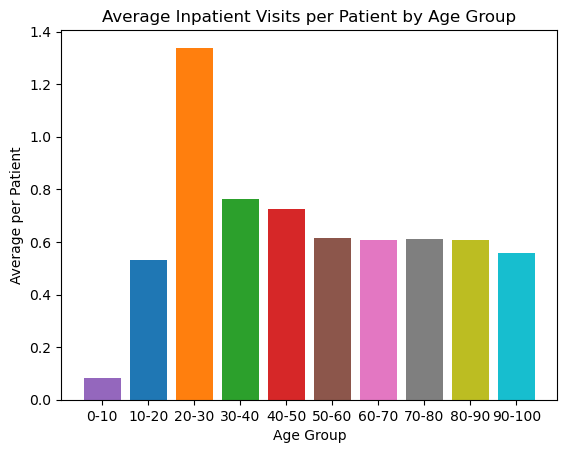

In [211]:
# A bar graph for average inpatient visits.
fig, ax = plt.subplots()
ax.bar(labels, df1, color=colors)
ax.set_ylabel('Average per Patient')
ax.set_xlabel('Age Group')
ax.set_title('Average Inpatient Visits per Patient by Age Group')

Text(0.5, 1.0, 'Average Outpatient Visits per Patient by Age Group')

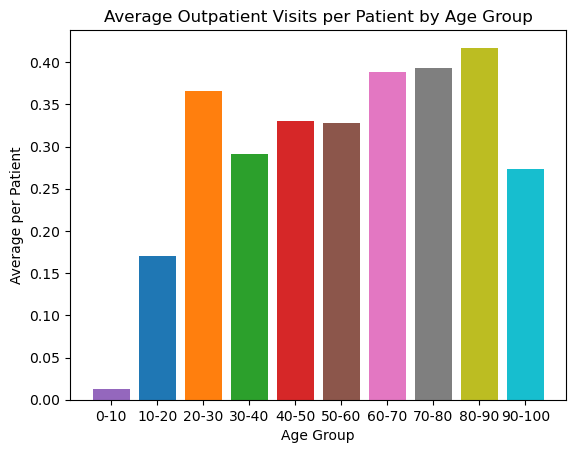

In [212]:
# A bar graph for average oupatient visits.
fig, ax = plt.subplots()
ax.bar(labels, df11, color=colors)
ax.set_ylabel('Average per Patient')
ax.set_xlabel('Age Group')
ax.set_title('Average Outpatient Visits per Patient by Age Group')

In [213]:
# We can see that 20-30 is by far the highest group for inpatient visits, and outpatient visits stays fairly consistent after 20-30, peaking at 80-90.
# It can be assumed that 20-30 is the age that more first diagnoses are made, requiring more intensive inpatient visits. After, the patients may have adjusted and only require regular outpatient visits for checkups.
# It can also be assumed that outpatient vists stay consistent after diagnosis. 

Text(0.5, 1.0, 'Average Diagnoses per Patient by Age Group')

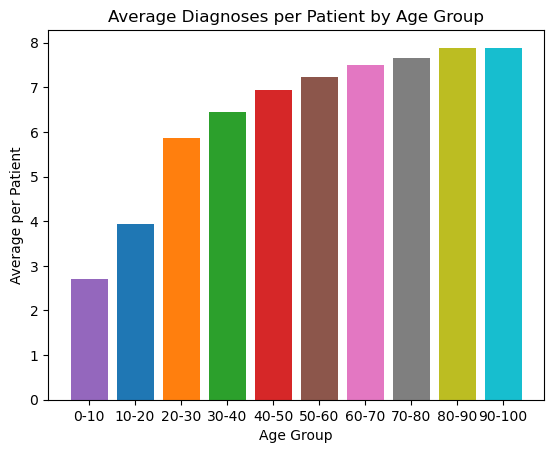

In [214]:
# A bar graph for average diagnoses.
fig, ax = plt.subplots()
ax.bar(labels, df2, color=colors)
ax.set_ylabel('Average per Patient')
ax.set_xlabel('Age Group')
ax.set_title('Average Diagnoses per Patient by Age Group')

In [215]:
# We can see that diagnoses steadily increase with age.
# It can be assumed that diagnoses can increase overtime as the disease develops.

Text(0.5, 1.0, 'Average Procedures per Patient by Age Group')

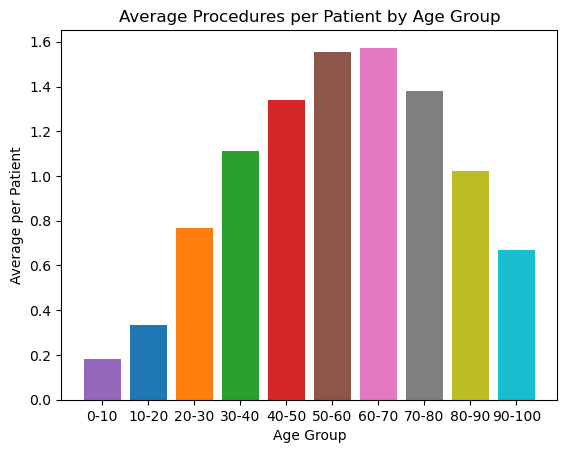

In [216]:
# A bar graph for average procedures.
fig, ax = plt.subplots()
ax.bar(labels, df3, color=colors)
ax.set_ylabel('Average per Patient')
ax.set_xlabel('Age Group')
ax.set_title('Average Procedures per Patient by Age Group')

In [217]:
# We can see that procedures increase from early age onwards, peaking at 60-70, with a steady drop off after.
# It can be assumed that older patients may be less likely to get procedures as it can be more complicated with age or recovery may be more difficult at older ages.

Text(0.5, 1.0, 'Average Emergency Visits per Patient by Age Group')

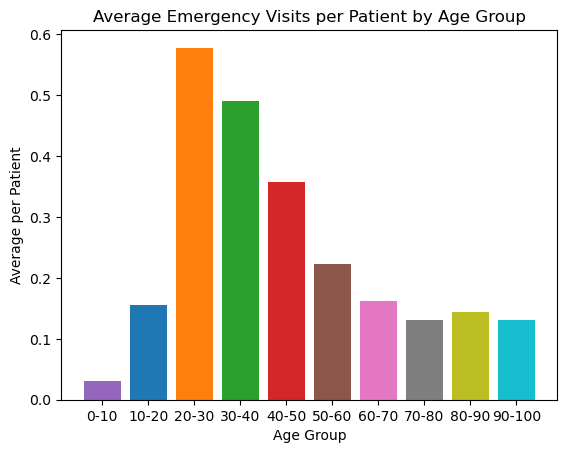

In [218]:
# A bar graph for average emergency visits.
fig, ax = plt.subplots()
ax.bar(labels, df4, color=colors)
ax.set_ylabel('Average per Patient')
ax.set_xlabel('Age Group')
ax.set_title('Average Emergency Visits per Patient by Age Group')

In [219]:
# Similar to inpatient visits, we can see emergency visits spike at 20-30 and steadily drop after.
# It can be assumed that individuals may be undiagnosed and untreated at early ages, which leads to more extreme situations as the patient reaches their 20s and 30s.

In [220]:
# Based on our analysis, we can see that although our 70-80 age group has the highest amount of diagnoses, it does not have the highest average inpatient visits, outpatient visits, diagnoses, procedures, or emergency visits per patient. Based on the data given we cannot extrapolate any solid conclusions, and the higher averages could be due to certain age groups being more at risk, requiring more immediate care, or due to outliers. With further research and data, this analysis could be used as supplementary evidence for hypotheses as to why each age group averaged how it did in these categories. A helpful column in this analysis would have been an indication of when the patient was first diagnosed.